# Signal Analysis Walkthrough

This notebook is the interview-facing walkthrough for the reusable signal-processing pipeline. It uses synthetic records first so the workflow runs without private data.

## 1. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from signal_processing_prep.config import load_config
from signal_processing_prep.features import FeatureExtractionConfig, frequency_bands_from_mapping
from signal_processing_prep.frequency_domain import dominant_frequency, fft_magnitude, psd
from signal_processing_prep.modeling import run_isolation_forest, top_anomalies
from signal_processing_prep.pipeline import AnalysisPipelineConfig, analyze_records
from signal_processing_prep.plotting import (
    plot_anomaly_scores,
    plot_feature_distribution,
    plot_frequency_spectrum,
    plot_spectrogram,
    plot_time_signal,
    save_figure,
)
from signal_processing_prep.preprocessing import FilterSpec, apply_filter
from signal_processing_prep.quality import assess_dataset_quality
from signal_processing_prep.reporting import save_markdown_summary
from signal_processing_prep.synthetic import make_synthetic_dataset


In [2]:
from IPython import get_ipython

ip = get_ipython()
if ip is None:
    print("No IPython kernel detected; cannot configure matplotlib backend.")
else:
    try:
        ip.run_line_magic("matplotlib", "widget")
        print("Configured matplotlib for interactive widget backend.")
    except Exception:
        try:
            ip.run_line_magic("matplotlib", "inline")
            print("Interactive widget backend unavailable; using inline backend.")
        except Exception:
            print("Failed to configure matplotlib backend; proceeding with default settings.")

Configured matplotlib for interactive widget backend.


## 2. Load Configuration And Synthetic Records

In [3]:
config_path = Path("configs/synthetic.yaml")
if not config_path.exists():
    config_path = Path("../configs/synthetic.yaml")
config = load_config(config_path)
records = make_synthetic_dataset()

[(record.name, record.label, record.n_samples, record.sampling_rate_hz) for record in records]


[('sine_wave', 'sine', 1000, 1000.0),
 ('noisy_sine_wave', 'noisy_sine', 1000, 1000.0),
 ('impulse_train', 'impulse_train', 1000, 1000.0),
 ('chirp_signal', 'chirp', 1000, 1000.0),
 ('clipped_signal', 'clipped', 1000, 1000.0),
 ('transient_burst', 'transient_burst', 2000, 2000.0)]

## 3. Inspect Quality And Raw Time Signals

In [4]:
quality = assess_dataset_quality(records)
quality[["record_name", "duration_seconds", "missing_fraction", "is_clipped", "issues"]]


,record_name,duration_seconds,missing_fraction,is_clipped,issues
0,sine_wave,1.0,0.0,False,
1,noisy_sine_wave,1.0,0.0,False,
2,impulse_train,1.0,0.0,True,possible_clipping
3,chirp_signal,1.0,0.0,False,
4,clipped_signal,1.0,0.0,True,possible_clipping
5,transient_burst,1.0,0.0,False,nonstationarity_indicator


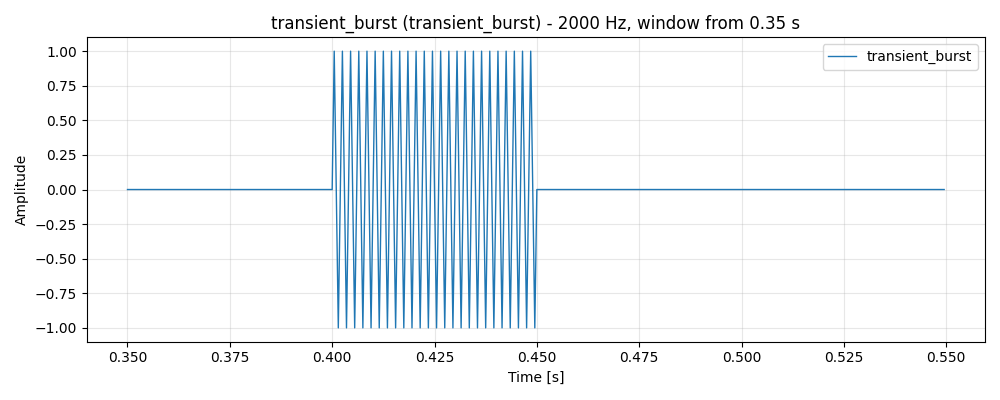

In [5]:
fig, ax = plot_time_signal(records[-1], start_seconds=0.35, duration_seconds=0.2)
plt.show()


## 4. Frequency And Time-Frequency Views

In [6]:
record = records[0]
spectrum = fft_magnitude(record)
power = psd(record)

dominant_frequency(spectrum), dominant_frequency(power)


(50.0, 50.0)

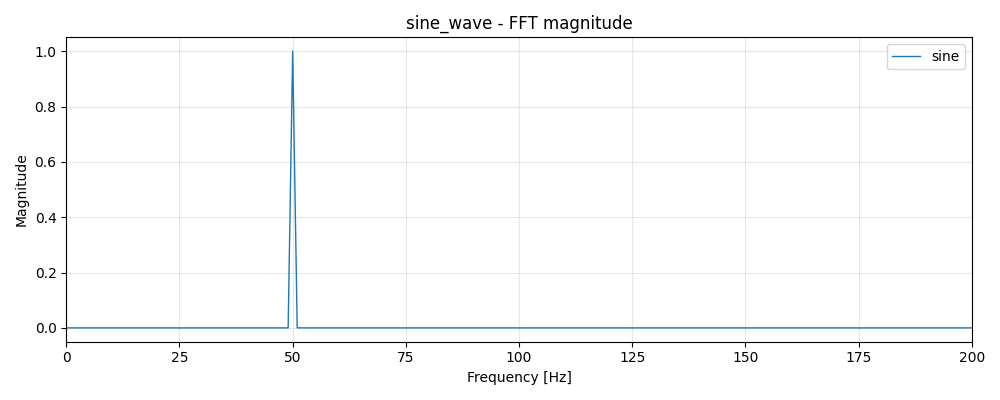

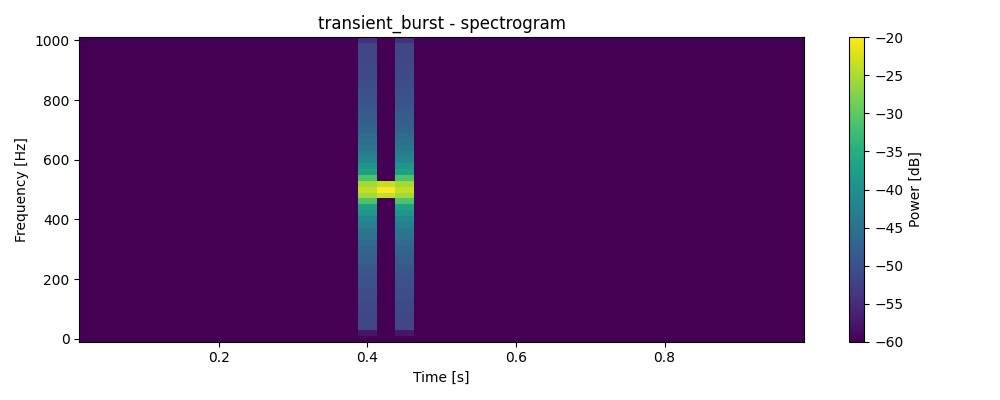

In [11]:
fig, ax = plot_frequency_spectrum(records[0], spectrum_type="fft", max_frequency_hz=200)
plt.show()

fig, ax = plot_spectrogram(records[-1], window_seconds=0.05, 
                           step_seconds=0.025, max_frequency_hz=1000,
                           vmin_db=-60, vmax_db=-20)
plt.show()


## 5. Optional Filtering

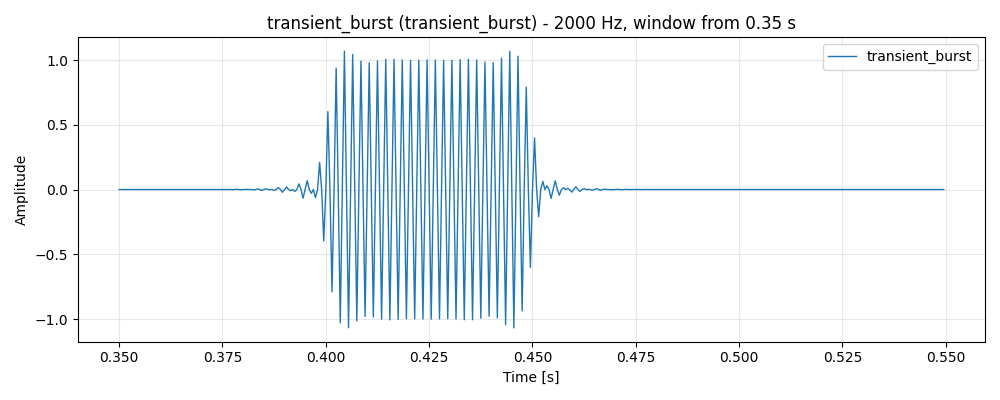

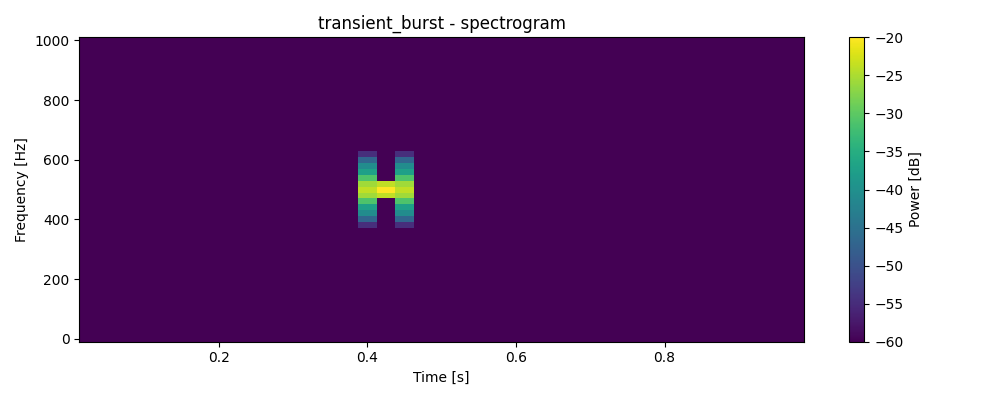

In [12]:
filtered = apply_filter(records[-1], FilterSpec(kind="bandpass", low_cut_hz=400.0, high_cut_hz=600.0))
fig, ax = plot_time_signal(filtered, start_seconds=0.35, duration_seconds=0.2)
plt.show()
fig, ax = plot_spectrogram(filtered, window_seconds=0.05, step_seconds=0.025, 
                           max_frequency_hz=1000, vmin_db=-60, vmax_db=-20)
plt.show()


## 6. Feature Extraction

In [13]:
bands = frequency_bands_from_mapping(config.analysis.frequency_bands_hz)
pipeline_config = AnalysisPipelineConfig(
    frequency_bands=bands,
    random_state=0,
)
result = analyze_records(records, pipeline_config)
features = result.features
features.head()


,record_name,label,sampling_rate_hz,n_samples,duration_seconds,mean,std,min,max,peak_to_peak,...,spectral_bandwidth_hz,spectral_rolloff_85_hz,spectral_flatness,band_energy_low,band_energy_bearing_like,band_energy_high,spectral_entropy,mean_spectrogram_energy,max_spectrogram_energy,high_frequency_transient_energy
0,sine_wave,sine,1000.0,1000.0,1.0,1.221245e-16,0.707107,-1.000000,1.00000,2.000000,...,0.000099,50.0,5.294072e-10,0.500000,4.108936e-29,NaN,1.405080e-27,0.000980,0.033333,3.304129e-30
1,noisy_sine_wave,noisy_sine,1000.0,1000.0,1.0,-4.802828e-03,0.715043,-1.203127,1.16275,2.365877,...,151.501630,398.0,5.987670e-01,0.503622,7.664281e-03,NaN,3.222503e-02,0.001004,0.035261,4.337060e-04
2,impulse_train,impulse_train,1000.0,1000.0,1.0,2.000000e-02,0.140000,0.000000,1.00000,1.000000,...,141.509680,420.0,1.726059e-09,0.003200,1.640000e-02,NaN,5.151860e-01,0.000051,0.000053,6.666667e-04
3,chirp_signal,chirp,1000.0,1000.0,1.0,7.152329e-03,0.707021,-0.999999,1.00000,1.999999,...,64.581492,180.0,2.129212e-01,0.220851,2.790282e-01,NaN,8.425028e-01,0.000982,0.031788,1.581289e-10
4,clipped_signal,clipped,1000.0,1000.0,1.0,2.149392e-16,0.835729,-1.000000,1.00000,2.000000,...,60.691513,150.0,4.611895e-10,0.682835,1.560693e-02,NaN,1.779432e-02,0.001369,0.045522,2.322762e-06


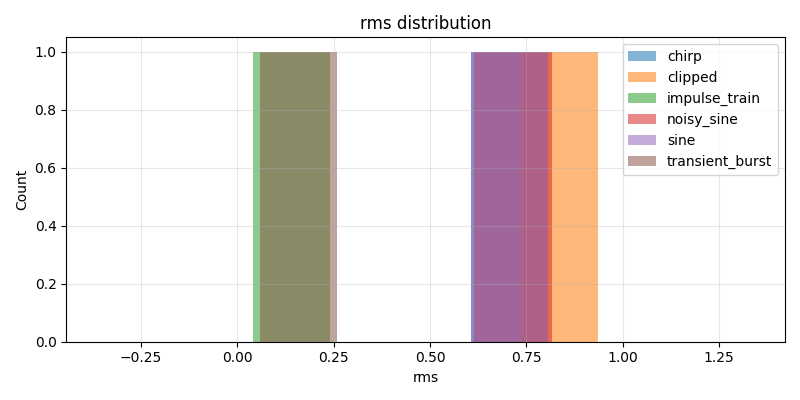

In [14]:
fig, ax = plot_feature_distribution(features, "rms")
plt.show()


## 7. Optional Modeling And Anomaly Scoring

In [15]:
anomaly = result.anomaly_model or run_isolation_forest(features, random_state=0)
top_anomalies(anomaly, n=5)


,row_index,anomaly_score,isolation_forest_prediction,record_name,label
0,2,0.072747,-1,impulse_train,impulse_train
1,5,0.000709,-1,transient_burst,transient_burst
2,3,-0.018416,1,chirp_signal,chirp
3,1,-0.046531,1,noisy_sine_wave,noisy_sine
4,4,-0.075516,1,clipped_signal,clipped


In [ ]:
fig, ax = plot_anomaly_scores(anomaly.predictions, top_n=5)
plt.show()


## 8. Markdown Summary

In [ ]:
print(result.markdown_summary)

# Uncomment to write the summary and selected figure during a real run.
# summary_path = save_markdown_summary(result.markdown_summary, Path("../reports/summaries"))
# figure_path = save_figure(fig, Path("../reports/figures"), stem="synthetic_anomaly_scores")
